# Linguistic Root Classifier: Logistic Regression

## Goal
This project classifies technical terms into two linguistic roots: Anglo-Saxon/Germanic ($y=0$) or Greek/Latin ($y=1$) using Logistic Regression built from first principles.

## Logistic Regression
Logistic regression is used for binary classification. It calculates the probability that a given input belongs to the positive class (in this case, a Greek/Latin root).

### The Hypothesis
The model maps a linear combination of features to a probability between 0 and 1 using the Sigmoid (logistic) function:
$$g(z) = \frac{1}{1+e^{-z}}$$

Here, the linear combination $z$ is defined as:
$$z = \vec{w} \cdot \vec{x} + b$$

Thus, the hypothesis function is:
$$f_{\vec{w}, b}(\vec{x}) = g(z) = P(y=1|\vec{x}; \vec{w}, b)$$
* $\vec{w}$ is the weights vector.
* $\vec{x}$ is the features vector.
* $b$ is the bias scalar.

### Decision Boundary
The threshold $f_{\vec{w}, b}(\vec{x}) = 0.5$ separates the probability space into two equal parts. 
* When $f_{\vec{w}, b}(\vec{x}) \ge 0.5$, we predict $y=1$.
* When $f_{\vec{w}, b}(\vec{x}) < 0.5$, we predict $y=0$.

Mathematically, $g(z) = 0.5$ when $z = 0$. Therefore, the equation $\vec{w} \cdot \vec{x} + b = 0$ defines the exact decision boundary of the model.

### Cost Function
To evaluate the model's performance, we measure the error between our predicted probabilities and the actual linguistic roots. We avoid Mean Squared Error (MSE) because, when combined with the non-linear Sigmoid function, MSE creates a non-convex graph with multiple local minima. Instead, we use Log Loss, which guarantees a single global minimum.

#### Log Loss (Binary Cross-Entropy) for a Single Example
$$L(f_{\vec{w}, b}(\vec{x}^{(i)}), y^{(i)}) = \begin{cases}
-\log(f_{\vec{w}, b}(\vec{x}^{(i)})) & \text{if } y^{(i)}=1\\
-\log(1-f_{\vec{w}, b}(\vec{x}^{(i)})) & \text{if } y^{(i)}=0
\end{cases}$$

Since $y^{(i)}$ is strictly $1$ or $0$, we can compress this piecewise function into a single elegant equation:
$$L(f_{\vec{w}, b}(\vec{x}^{(i)}), y^{(i)}) = -y^{(i)}\log(f_{\vec{w}, b}(\vec{x}^{(i)})) - (1-y^{(i)})\log(1-f_{\vec{w}, b}(\vec{x}^{(i)}))$$

#### Total Cost Function
The total cost $J$ is the average loss across all $m$ training examples:
$$J(\vec{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)}\log(f_{\vec{w}, b}(\vec{x}^{(i)})) + (1-y^{(i)})\log(1-f_{\vec{w}, b}(\vec{x}^{(i)}))]$$

### Optimization: Gradient Descent
To find the optimal weights that minimize our cost function, we compute the partial derivatives of $J$ with respect to $\vec{w}$ and $b$.

#### Partial Derivatives
$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (f_{\vec{w}, b}(\vec{x}^{(i)})-y^{(i)})x_j^{(i)}$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{\vec{w}, b}(\vec{x}^{(i)})-y^{(i)})$$

#### Vectorized Gradients
For computational efficiency, these derivatives are computed using matrix multiplication across the entire feature matrix $X$ and prediction vector $A$:
$$d\vec{w} = \frac{1}{m} X^T (A - Y)$$
$$db = \frac{1}{m} \sum (A - Y)$$

#### The Update Algorithm
Repeat the following updates simultaneously until convergence (when $J$ reaches its global minimum):
$$w_j = w_j - \alpha \frac{\partial J}{\partial w_j}$$
$$b = b - \alpha \frac{\partial J}{\partial b}$$
*(Where $\alpha$ is the learning rate, controlling the step size of the descent).*

# Background: Linguistic Roots of Technical English

English is a hybrid language. While its grammatical base is Germanic, its vocabulary is sharply divided due to historical shifts. This project exploits that divide by mathematically classifying words into two primary categories.

## 0. The Anglo-Saxon Foundation (Germanic Roots)
Established in the 5th century, these words form the bedrock of everyday human experience.
* **Characteristics:** Phonetic, structurally short (1-2 syllables), and feature hard consonant clusters (e.g., *str-*, *-ngth*).
* **Semantic Domain:** Basic, everyday concepts (*water, bone, earth, sleep*).

## 1. The Greco-Latin Overlay (The Language of Science)
During the Scientific Revolution, scholars needed precise, universal terms for new discoveries. Rather than repurposing everyday words, they engineered the **International Scientific Vocabulary (ISV)** using ancient Latin and Greek.
* **Characteristics:** Multisyllabic, built modularly with standard prefixes/suffixes (*macro-*, *-ology*), and feature unique consonant behaviors (e.g., *ph* as 'f', silent *ps-*).
* **Semantic Domain:** Academic, medical, and highly technical concepts (*photosynthesis, algorithm*).

## Structural Features for Machine Learning
Because Greco-Latin scientific terms were deliberately constructed rather than naturally evolved, they possess distinct mathematical properties that a Logistic Regression model can learn:
1. **Syllable Density:** Technical terms are statistically longer.
2. **Vowel-to-Consonant Ratios:** Greek/Latin terms often feature different vowel distribution patterns compared to Germanic consonant clusters.
3. **Specific N-grams:** The presence of specific letter sequences (like "ch" pronounced as 'k', or the suffix "-tion") heavily weights probability toward a Greco-Latin origin.

---
### Sources
* [International Scientific Vocabulary (Wikipedia)](https://en.wikipedia.org/wiki/International_scientific_vocabulary)
* [Online Etymology Dictionary (Etymonline)](https://www.etymonline.com/)


# Code

## Creating the dataset

In [1]:
import ety
import pandas as pd
import nltk
from nltk.corpus import words

nltk.download('words')
english_words = words.words()

dataset = []

for word in english_words[0: 20000]:
    origins = ety.origins(word)
    if origins:
        root_lang = origins[0].language.name
        if root_lang in ['Latin', 
                         'Ancient Greek (to 1453)',
                         'Ancient Greek', \
                         'Late Latin', 
                         'Anglo-Norman',
                         'Middle French',
                         'Old French (842-ca. 1400)',
                        ]:
            dataset.append({'word': word, 'root': 'Greco-Latin', 'label': 1})
        elif root_lang in ['Old English (ca. 450-1100)', 
                           'Proto-Germanic', 
                           'Middle English (1100-1500)', 
                           'Old High German (ca. 750-1050)',
                           'Old Norse',
                           'Dutch'
                          ]:
            dataset.append({'word': word, 'root': 'Germanic', 'label': 0})
df = pd.DataFrame(dataset)
print(df.head(10))
print(f"Total labeled words: {len(df)}")

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\dulan\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


         word         root  label
0           a     Germanic      0
1   abacinate  Greco-Latin      1
2     abactor  Greco-Latin      1
3    abaculus  Greco-Latin      1
4      abacus  Greco-Latin      1
5  abalienate  Greco-Latin      1
6  abaptiston  Greco-Latin      1
7       abate     Germanic      0
8     abature  Greco-Latin      1
9      abbacy     Germanic      0
Total labeled words: 1217


## Feature Engineering
In order to categorise words, we need a numerical representation of some main features of the words, which facilitates categorization.
### Main Features
1. Length of the word ($x_1$): Anglo-saxon words are structurally short compared to greco-latin origin words.
2. Vowel-to-constant ratio ($x_2$): Germanic words tolerate heavy consonant clusters (like "strength"). Latin and Greek terms tend to alternate vowels and consonants more predictably.
3. Greek Cluster Flag ($x_3$) (binary): Greco-Latin feature unique consonant behaviors (e.g., ph as 'f', silent ps-).
4. Latin Suffix Flag ($x_4$) (binary): Availability of suffixes like "-tion", "-ology", "-ism", or "-ity".

In [2]:
import re

def calc_vc_ratio(word):
    vowels = len(re.findall(r"[aeiouAEIOU]", word))
    constants = len(word) - vowels
    return vowels/constants if constants>0 else 0

df["x1_length"] = df['word'].apply(len)
df['x2_vc_ratio'] = df['word'].apply(calc_vc_ratio)
df['x3_greek_cluster'] = df['word'].str.contains(r'ph|ps|ch|rh|pn|pt|th|qu|sc|cc|ti|ci').astype(int)
latin_suffix_pattern = r"\b\w+(?:able|ible|ation|ition|tion|sion|ment|ance|ence|ity|ty|al|ar|or|er|ant|ent|ous|ious|ive|ate|ify|ize|ise)\b"
df['x4_latin_suffix'] = df['word'].str.contains(latin_suffix_pattern).astype(int)
print(df.head(10))

         word         root  label  x1_length  x2_vc_ratio  x3_greek_cluster  \
0           a     Germanic      0          1     0.000000                 0   
1   abacinate  Greco-Latin      1          9     1.250000                 1   
2     abactor  Greco-Latin      1          7     0.750000                 0   
3    abaculus  Greco-Latin      1          8     1.000000                 0   
4      abacus  Greco-Latin      1          6     1.000000                 0   
5  abalienate  Greco-Latin      1         10     1.500000                 0   
6  abaptiston  Greco-Latin      1         10     0.666667                 1   
7       abate     Germanic      0          5     1.500000                 0   
8     abature  Greco-Latin      1          7     1.333333                 0   
9      abbacy     Germanic      0          6     0.500000                 0   

   x4_latin_suffix  
0                0  
1                1  
2                1  
3                0  
4                0  
5   

### Adding more features to capture any non linear relationships of features

In [3]:
df['x1_squared'] = df['x1_length'].apply(lambda x: x**2)
df['x1_cube'] = df['x1_length'].apply(lambda x: x**3)
df['x2_squared'] = df['x2_vc_ratio'].apply(lambda x: x**2)
df['x2_cube'] = df['x2_vc_ratio'].apply(lambda x: x**3)

print(df.head(10))

         word         root  label  x1_length  x2_vc_ratio  x3_greek_cluster  \
0           a     Germanic      0          1     0.000000                 0   
1   abacinate  Greco-Latin      1          9     1.250000                 1   
2     abactor  Greco-Latin      1          7     0.750000                 0   
3    abaculus  Greco-Latin      1          8     1.000000                 0   
4      abacus  Greco-Latin      1          6     1.000000                 0   
5  abalienate  Greco-Latin      1         10     1.500000                 0   
6  abaptiston  Greco-Latin      1         10     0.666667                 1   
7       abate     Germanic      0          5     1.500000                 0   
8     abature  Greco-Latin      1          7     1.333333                 0   
9      abbacy     Germanic      0          6     0.500000                 0   

   x4_latin_suffix  x1_squared  x1_cube  x2_squared   x2_cube  
0                0           1        1    0.000000  0.000000  
1 

## Feature Scaling

In [4]:
df["x1_length"] = (df["x1_length"] - df["x1_length"].mean())/df["x1_length"].std()
df["x2_vc_ratio"] = (df["x2_vc_ratio"] - df["x2_vc_ratio"].mean())/df["x2_vc_ratio"].std()
df["x1_squared"] = (df["x1_squared"] - df["x1_squared"].mean()) / df["x1_squared"].std()
df["x1_cube"] = (df["x1_cube"] - df["x1_cube"].mean()) / df["x1_cube"].std()
df["x2_squared"] = (df["x2_squared"] - df["x2_squared"].mean()) / df["x2_squared"].std()
df["x2_cube"] = (df["x2_cube"] - df["x2_cube"].mean()) / df["x2_cube"].std()
print(df.head(10))

         word         root  label  x1_length  x2_vc_ratio  x3_greek_cluster  \
0           a     Germanic      0  -2.786786    -2.165483                 0   
1   abacinate  Greco-Latin      1   0.668218     0.803097                 1   
2     abactor  Greco-Latin      1  -0.195533    -0.384335                 0   
3    abaculus  Greco-Latin      1   0.236343     0.209381                 0   
4      abacus  Greco-Latin      1  -0.627408     0.209381                 0   
5  abalienate  Greco-Latin      1   1.100094     1.396812                 0   
6  abaptiston  Greco-Latin      1   1.100094    -0.582241                 1   
7       abate     Germanic      0  -1.059284     1.396812                 0   
8     abature  Greco-Latin      1  -0.195533     1.001002                 0   
9      abbacy     Germanic      0  -0.627408    -0.978051                 0   

   x4_latin_suffix  x1_squared   x1_cube  x2_squared   x2_cube  
0                0   -1.643849 -1.116491   -0.768743 -0.298676  


## Defining vectors and matrices

In [5]:
import numpy as np

In [6]:
#X feature matrix
features = ['x1_length', 'x2_vc_ratio', 'x3_greek_cluster', 'x4_latin_suffix', 'x1_squared', 'x1_cube', 'x2_squared', 'x2_cube']
x_train = df[features].to_numpy() 

num_of_features = np.shape(x_train)[1] 
#weights and b
w_init = np.zeros(num_of_features)
b_init=0

In [7]:
#prediction function
def predict(X, w, b):
    z = np.dot(X, w) + b  
    prediction_vector = 1/(1+np.exp(-z))
    return prediction_vector

In [8]:
#cost function
def cost(X, w, b, Y):
    prediction = predict(X, w, b)
    m = np.shape(Y)[0]
    cost = -(np.dot(Y, np.log(prediction)) + np.dot(1-Y, np.log(1-prediction)))/m
    
    return cost.item()

## Running gradient decent

In [9]:
import math

In [10]:
# A = predict(x_train, w, b) #prediction vector of order m
Y = df['label'].to_numpy() #training label vector of order m
X_transpose = np.transpose(x_train) #transpose of training feature matrix
print(np.shape(X_transpose))

def run_gradient_decent(x_train, Y, alpha, w, b, max_iterations, ):
    """ Return w, b and J_history"""
    m = np.shape(Y)[0]
    X_T = np.transpose(x_train) #transpose of training feature matrix
    convergence = False
    iterations = 0
    J_history = []
    while ((not convergence) and iterations<max_iterations):
        A = predict(x_train, w, b) #prediction vector of order m
        J_w = X_T.dot(A-Y)/m
        J_b = np.sum(A-Y)/m
        w_prev = w
        b_prev = b
        w = w - alpha*J_w
        b = b - alpha*J_b
        iterations += 1
        J_history.append(cost(x_train, w, b, Y))
        if(np.allclose(w, w_prev) and math.isclose(b, b_prev)):
            convergence  = True
            print(f"Converged by {iterations} iterations")
    return w, b, J_history



(8, 1217)


### Weights, b and cost values per iteration after gradient decent

In [11]:
w, b, J_history= run_gradient_decent(x_train=x_train, Y=Y, alpha=0.05, w=w_init, b=b_init, max_iterations = 5000) 
print(w , b)

[ 1.55875411  0.72149171  0.26661385 -0.20176886  0.26642714 -0.70404195
 -0.2428914  -0.05466814] 1.3936083480029913


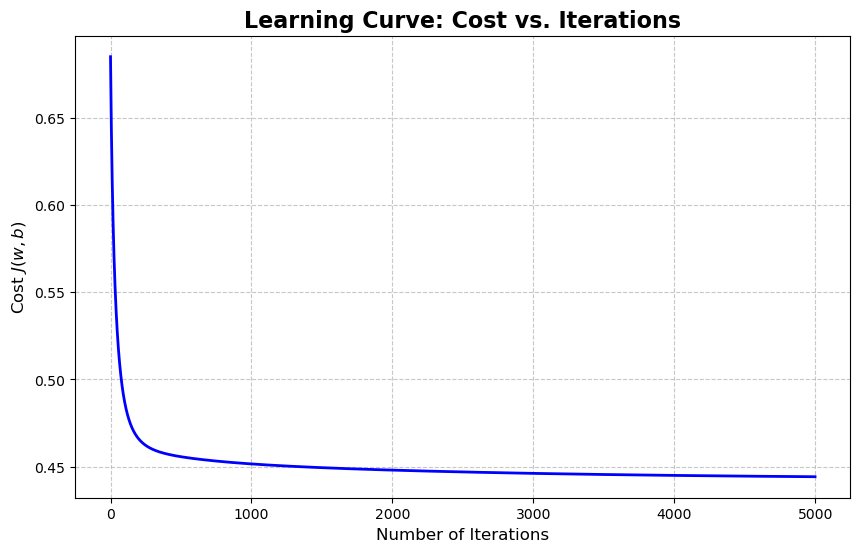

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cost(J_history):
    # 1. Create the figure and set the size
    plt.figure(figsize=(10, 6))
    
    # 2. Plot the cost history
    # We use np.arange to generate the x-axis (iteration numbers) based on the length of J_history
    plt.plot(np.arange(len(J_history)), J_history, color='blue', linewidth=2)
    
    # 3. Add labels and a title to make it portfolio-ready
    plt.title("Learning Curve: Cost vs. Iterations", fontsize=16, fontweight='bold')
    plt.xlabel("Number of Iterations", fontsize=12)
    plt.ylabel("Cost $J(w, b)$", fontsize=12)
    
    # 4. Add a grid for easier reading
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 5. Render the plot
    plt.show()

plot_cost(J_history)

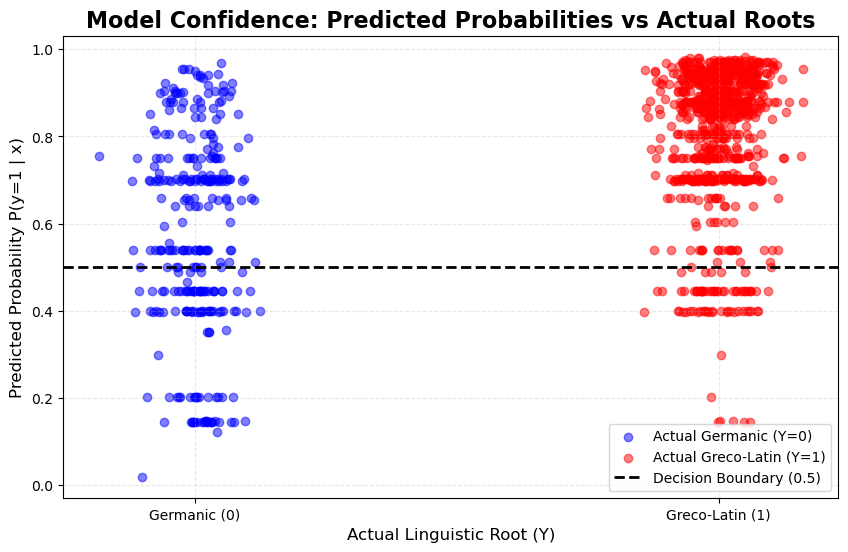

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_prediction(X, Y, w, b):
    '''Plot and return prediction vector'''
    predictions = predict(X, w, b)
    
    # Create the figure
    plt.figure(figsize=(10, 6))
    
    # 1. Create 'jitter' so the points don't perfectly overlap on the x-axis
    jitter = np.random.normal(0, 0.05, size=len(Y))
    
    # 2. Plot Class 0 (Germanic Roots)
    plt.scatter(Y[Y == 0] + jitter[Y == 0], predictions[Y == 0], 
                color='blue', alpha=0.5, label='Actual Germanic (Y=0)')
    
    # 3. Plot Class 1 (Greco-Latin Roots)
    plt.scatter(Y[Y == 1] + jitter[Y == 1], predictions[Y == 1], 
                color='red', alpha=0.5, label='Actual Greco-Latin (Y=1)')
    
    # 4. Draw the mathematical decision boundary
    plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
    
    # 5. Make it portfolio-ready
    plt.title("Model Confidence: Predicted Probabilities vs Actual Roots", fontsize=16, fontweight='bold')
    plt.xlabel("Actual Linguistic Root (Y)", fontsize=12)
    plt.ylabel("Predicted Probability P(y=1 | x)", fontsize=12)
    
    # Force the x-axis to only show our two binary labels
    plt.xticks([0, 1], ['Germanic (0)', 'Greco-Latin (1)'])
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()
    return predictions

predictions = plot_prediction(x_train, Y, w ,b)

In [14]:
# Convert probabilities to strict 0 or 1 using a vectorized numpy operation
final_classifications = (predictions >= 0.5).astype(int)

# Calculate the accuracy percentage
accuracy = np.mean(final_classifications == Y) * 100
print(f"Final Model Accuracy: {accuracy:.2f}%")

Final Model Accuracy: 78.80%


# Analysis of results
From the above plot, it is clearly observed that the model is correctly categorizing a considarable number of greco-latin words. However, it shows a poor performance on categorizing germanic words.

Lack of adequate features that supports in categorizing germanic words apart from x1_length and x2_vc_ratio can be suspected as the main cause. Therefore, in the rest of this notebook, we introduce a new feature called x5_germanic_cons to target germanic consonant structures such as "ght", "th", "sh", or "kn" in words.

[ 1.56462905  0.70023757  0.36042937 -0.22986481  0.26560944 -0.70905134
 -0.2361966  -0.04930868 -0.56939569] 1.4104446619131192


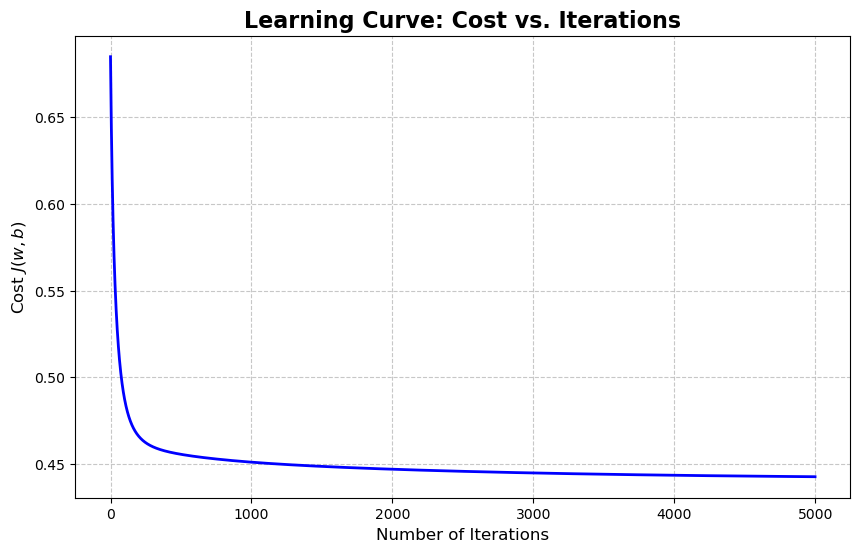

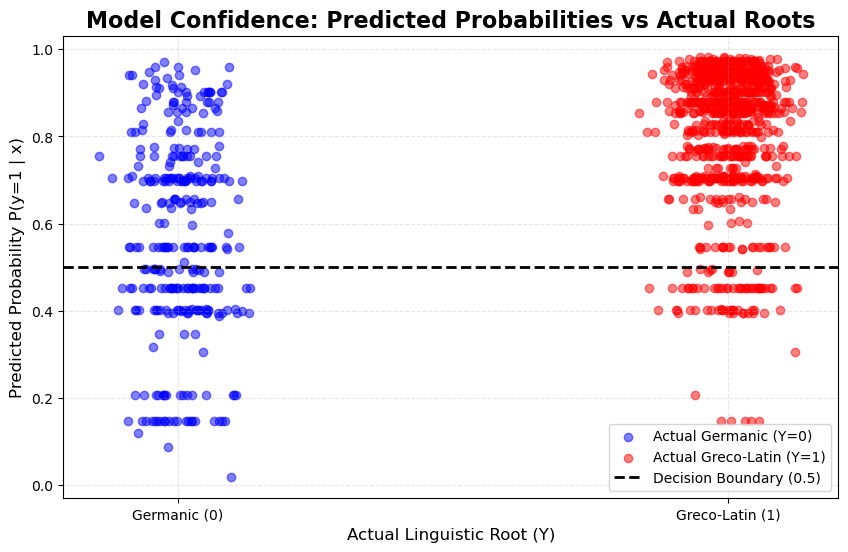

In [15]:
new_features = features+['x5_germanic_cons']
germanic_consonant_pattern = r"ght|th|sh|kn|wh|wr"
df['x5_germanic_cons'] = df['word'].str.contains(germanic_consonant_pattern).astype(int)
x_train_new = df[new_features].to_numpy()

new_num_of_features = np.shape(x_train_new)[1] 
#weights and b
w_init_new = np.zeros(new_num_of_features)
b_init_new=0

w_new, b_new, J_history_new = run_gradient_decent(x_train=x_train_new, Y=Y, alpha=0.05, w=w_init_new, b=b_init_new, max_iterations = 5000) 
print(w_new , b_new)

plot_cost(J_history_new)

new_predictions = plot_prediction(x_train_new, Y, w_new ,b_new)

In [16]:
# Convert probabilities to strict 0 or 1 using a vectorized numpy operation
new_final_classifications = (new_predictions >= 0.5).astype(int)

# Calculate the accuracy percentage
new_accuracy = np.mean(new_final_classifications == Y) * 100
print(f"Final Model Accuracy: {new_accuracy:.2f}%")

Final Model Accuracy: 78.96%


# Finding errorsome predictions

In [17]:
# 1. Convert probabilities to strict 0 or 1 predictions
predictions_binary = (new_predictions >= 0.5).astype(int)

# 2. Boolean masking to isolate the failures
# False Positives: Actual is 0 (Germanic), but Model guessed 1 (Latin)
false_positives = df[(Y == 0) & (predictions_binary == 1)]['word'].tolist()

# False Negatives: Actual is 1 (Latin), but Model guessed 0 (Germanic)
false_negatives = df[(Y == 1) & (predictions_binary == 0)]['word'].tolist()

print(f"Total False Positives: {len(false_positives)}")
print(f"Sample of False Positives:\n{false_positives[:30]}\n")

print(f"Total False Negatives: {len(false_negatives)}")
print(f"Sample of False Negatives:\n{false_negatives[:30]}")

Total False Positives: 176
Sample of False Positives:
['abate', 'abbacy', 'abbatial', 'abear', 'abele', 'abide', 'abject', 'abjure', 'ablactation', 'abode', 'abolish', 'aboon', 'about', 'abrade', 'abraid', 'absence', 'abstainer', 'abstinent', 'abuse', 'accidently', 'accurse', 'acquaint', 'acquire', 'acquit', 'across', 'action', 'active', 'actual', 'address', 'adeling']

Total False Negatives: 80
Sample of False Negatives:
['abort', 'absent', 'acerb', 'acme', 'acrid', 'act', 'actor', 'ad', 'Adam', 'add', 'adunc', 'agent', 'agon', 'agony', 'aid', 'alary', 'alas', 'Alban', 'album', 'alfet', 'allot', 'alloy', 'alogy', 'altar', 'alter', 'alum', 'amah', 'ambit', 'amble', 'ambo']


# Conclusion

While the addition of the new consonant feature marginally improved model accuracy, a noticeable error rate remained in the Germanic classification. However, a deeper error analysis of the false positives revealed a critical insight: the mathematical engine correctly identified numerous Greco-Latin words that were historically mislabeled as Germanic within the training data. This underlying data corruption accounts for the dense cluster of false positives above the 0.5 decision boundary. Ultimately, the model's misclassifications were driven by inherent flaws in the dataset rather than the logistic regression algorithm itself. This highlights the limitations of relying on manually engineered regex features to capture structural exceptions, indicating that a more robust, automated approach, such as N-Gram vectorization—is required moving forward.